# Boston House Price Prediction

## Objective
Predict house prices using housing attributes.

## Models Used
- Linear Regression
- Random Forest Regressor

## Best Model
Random Forest Regressor

## Best R² Score
0.888

In [1]:
from google.colab import files
uploaded = files.upload()


Saving HousingData.csv to HousingData.csv


In [2]:
import pandas as pd
df = pd.read_csv("HousingData.csv")

In [3]:
print(df.head())

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nInfo:")
print(df.info())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90    NaN  36.2  

Shape:
(506, 14)

Columns:
Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

Missing Values:
CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20


## Data Preprocessing

Missing values were identified and handled using mean imputation.

In [4]:
import pandas as pd

# Fill missing values with column means
df.fillna(df.mean(numeric_only=True), inplace=True)

# Verify
print(df.isnull().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


## Exploratory Data Analysis

Correlation analysis was performed to understand the relationship between features and house prices.

In [5]:
corr = df.corr()

print(corr['MEDV'].sort_values(ascending=False))

MEDV       1.000000
RM         0.695360
ZN         0.365943
B          0.333461
DIS        0.249929
CHAS       0.179882
CRIM      -0.379695
AGE       -0.380223
RAD       -0.381626
NOX       -0.427321
TAX       -0.468536
INDUS     -0.478657
PTRATIO   -0.507787
LSTAT     -0.721975
Name: MEDV, dtype: float64


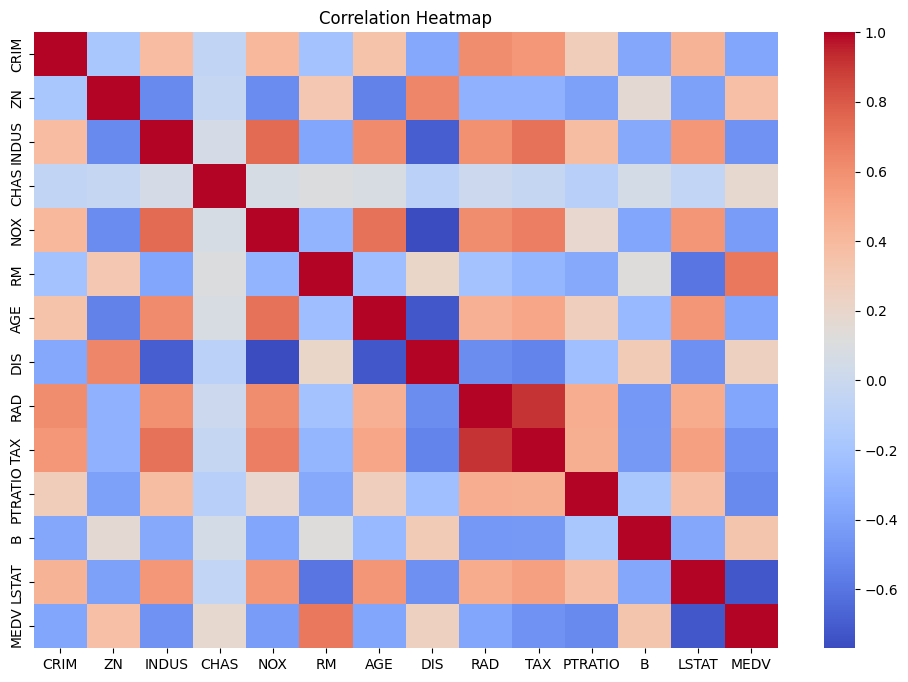

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Model Building

A Linear Regression model was trained as a baseline model.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Features and target
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R2 Score :", r2)
print("MSE      :", mse)
print("RMSE     :", rmse)

R2 Score : 0.6588520195508143
MSE      : 25.01767202384268
RMSE     : 5.0017668901941725


## Random Forest Regressor

A Random Forest model was trained and compared against Linear Regression.

In [8]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
print("Random Forest Results")
print("R2 Score :", rf_r2)
print("MSE      :", rf_mse)
print("RMSE     :", rf_rmse)

Random Forest Results
R2 Score : 0.8878080447367498
MSE      : 8.227460519607844
RMSE     : 2.8683550197993


## Feature Importance Analysis

Feature importance scores were extracted from the Random Forest model to identify the most influential housing attributes.

In [9]:
import pandas as pd
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
print(feature_importance)

    Feature  Importance
5        RM    0.560699
12    LSTAT    0.242797
7       DIS    0.059761
0      CRIM    0.042415
4       NOX    0.018138
9       TAX    0.017477
10  PTRATIO    0.017243
11        B    0.013651
6       AGE    0.012309
2     INDUS    0.007105
8       RAD    0.004370
1        ZN    0.002088
3      CHAS    0.001946


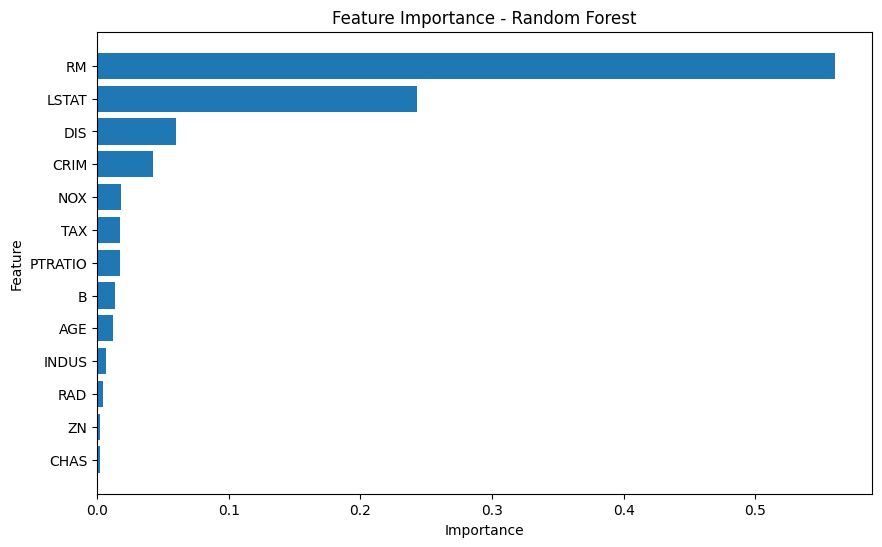

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")
plt.gca().invert_yaxis()
plt.show()

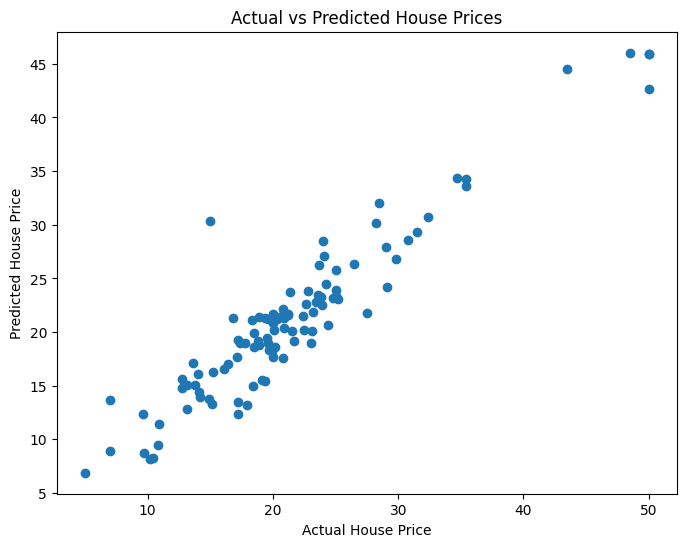

In [15]:
plt.figure(figsize=(8,6))
plt.scatter(
    y_test,
    rf_pred
)
plt.xlabel(
    "Actual House Price"
)
plt.ylabel(
    "Predicted House Price"
)
plt.title(
    "Actual vs Predicted House Prices"
)
plt.show()

## Prediction on New House Data

The trained Random Forest model is used to predict the price of a new house based on user-provided housing attributes.

In [26]:
new_house = pd.DataFrame({
    'CRIM':[0.03],
    'ZN':[20],
    'INDUS':[5],
    'CHAS':[0],
    'NOX':[0.5],
    'RM':[6],
    'AGE':[40],
    'DIS':[5],
    'RAD':[4],
    'TAX':[300],
    'PTRATIO':[15],
    'B':[390],
    'LSTAT':[5]
})

predicted_price = rf.predict(new_house)

print(
    "Predicted House Price:",
    predicted_price[0]
)

Predicted House Price: 23.263000000000005


# Conclusion

- Missing values were handled using mean imputation.
- Correlation analysis showed RM and LSTAT have strong influence on house prices.
- Linear Regression achieved an R² score of 0.659.
- Random Forest achieved an R² score of 0.888.
- Random Forest was selected as the final model.
- RM, LSTAT, DIS and CRIM were identified as the most important features.